In [1]:
import os, glob 
import numpy as np 
import matplotlib.pyplot as plt 
from utils import *

import os
import re
import glob
import ast
import numpy as np
import matplotlib.pyplot as plt

from optimizer import SolverSDPPerm
from utils import *

/Users/webb/Code/Lab/cloner/optimizer.py:1906: SyntaxWarning: invalid escape sequence '\o'
  """


### Define method

In [6]:
def _parse_fixed_irrep_filename(path):
    """
    Example:
    data/fixed_irrep/1_to_2_(1,)_to_(1,1)_nu_(1,).npz
    """
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]

    m = re.match(r"(\d+)_to_(\d+)_(\(.*?\))_to_(\(.*?\))_nu_(\(.*?\))$", stem)
    if m is None:
        return None

    n_in = int(m.group(1))
    n_out = int(m.group(2))
    part_in = tuple(ast.literal_eval(m.group(3)))
    part_out = tuple(ast.literal_eval(m.group(4)))
    part_nu = tuple(ast.literal_eval(m.group(5)))

    return {
        "n_in": n_in,
        "n_out": n_out,
        "partition_in": tuple(int(x) for x in part_in),
        "partition_out": tuple(int(x) for x in part_out),
        "partition_nu": tuple(int(x) for x in part_nu),
    }


def _safe_scalar(x):
    arr = np.asarray(x)
    if arr.shape == ():
        return arr.item()
    return x


def _maybe_tuple_from_npz_value(x):
    x = _safe_scalar(x)
    if isinstance(x, tuple):
        return tuple(int(v) for v in x)
    if isinstance(x, list):
        return tuple(int(v) for v in x)
    if isinstance(x, np.ndarray):
        if x.ndim == 1:
            return tuple(int(v) for v in x.tolist())
    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, tuple):
                return tuple(int(v) for v in y)
            if isinstance(y, list):
                return tuple(int(v) for v in y)
        except Exception:
            pass
    return None


def _partition_label(part):
    part = tuple(int(x) for x in part)
    return "(" + ",".join(str(x) for x in part) + ")"


def _partition_path_string(partition):
    return str(tuple(int(x) for x in partition)).replace(" ", "")


def _extract_local_block_from_npz(data):
    keys = list(data.keys())

    if "local_choi" in keys:
        return np.asarray(data["local_choi"], dtype=complex)

    tuple_like = []
    for k in keys:
        if re.fullmatch(r"\(\s*\d+\s*,\s*\d+\s*\)", k):
            tuple_like.append(k)

    if len(tuple_like) == 1:
        return np.asarray(data[tuple_like[0]], dtype=complex)

    for k in keys:
        if k.startswith("block_"):
            return np.asarray(data[k], dtype=complex)

    raise KeyError(
        f"Could not find local block in npz keys={keys}. "
        f"Expected 'local_choi' or a tuple-like key such as '(j2_out, j2_in)'."
    )


def load_all_fixed_irrep_maps(n_in, n_out, folder="data/fixed_irrep"):
    """ Read all fixed-irrep npz files for the given (n_in, n_out).
    Returns
    grouped : dict
        grouped[(j2_out, j2_in)] = [
            {
                "path": ...,
                "partition_in": ...,
                "partition_out": ...,
                "partition_nu": ...,
                "j2_in": ...,
                "j2_out": ...,
                "j2_nu": ...,
                "blocks": {(j2_out, j2_in): J_local},
                "npz": loaded_npz_metadata_dict,
            },
            ...
        ]
    """
    pattern = os.path.join(folder, f"{n_in}_to_{n_out}_*_nu_*.npz")
    paths = sorted(glob.glob(pattern))

    if len(paths) == 0:
        raise FileNotFoundError(f"No fixed-irrep files found for pattern: {pattern}")

    grouped = {}

    for path in paths:
        file_info = _parse_fixed_irrep_filename(path)

        with np.load(path, allow_pickle=True) as data:
            keys = list(data.keys())

            n_in_file = int(_safe_scalar(data["n_in"])) if "n_in" in keys else (file_info["n_in"] if file_info else None)
            n_out_file = int(_safe_scalar(data["n_out"])) if "n_out" in keys else (file_info["n_out"] if file_info else None)
            j2_in = int(_safe_scalar(data["j2_in"])) if "j2_in" in keys else None
            j2_out = int(_safe_scalar(data["j2_out"])) if "j2_out" in keys else None
            j2_nu = int(_safe_scalar(data["j2_nu"])) if "j2_nu" in keys else None

            part_in = None
            part_out = None
            part_nu = None

            if "partition_in" in keys:
                part_in = _maybe_tuple_from_npz_value(data["partition_in"])
            if "partition_out" in keys:
                part_out = _maybe_tuple_from_npz_value(data["partition_out"])
            if "partition_nu" in keys:
                part_nu = _maybe_tuple_from_npz_value(data["partition_nu"])

            if part_in is None and file_info is not None:
                part_in = file_info["partition_in"]
            if part_out is None and file_info is not None:
                part_out = file_info["partition_out"]
            if part_nu is None and file_info is not None:
                part_nu = file_info["partition_nu"]

            if j2_in is None and part_in is not None:
                j2_in, _ = parse_qubit_irrep_label(part_in, n_in_file)
            if j2_out is None and part_out is not None:
                j2_out, _ = parse_qubit_irrep_label(part_out, n_out_file)
            if j2_nu is None and part_nu is not None:
                j2_nu, _ = parse_qubit_irrep_label(part_nu, n_out_file - n_in_file)

            J = _extract_local_block_from_npz(data)
            key = (int(j2_out), int(j2_in))

            meta = {}
            for k in keys:
                try:
                    meta[k] = data[k]
                except Exception:
                    pass

            entry = {
                "path": path,
                "partition_in": tuple(part_in) if part_in is not None else tuple(j2_to_qubit_partition(n_in_file, j2_in)),
                "partition_out": tuple(part_out) if part_out is not None else tuple(j2_to_qubit_partition(n_out_file, j2_out)),
                "partition_nu": tuple(part_nu) if part_nu is not None else None,
                "j2_in": int(j2_in),
                "j2_out": int(j2_out),
                "j2_nu": int(j2_nu) if j2_nu is not None else None,
                "blocks": {key: J},
                "npz": meta,
            }

            grouped.setdefault(key, []).append(entry)

    # sort entries within each pair by j2_nu if present
    for key in grouped:
        grouped[key] = sorted(grouped[key], key=lambda x: (-1 if x["j2_nu"] is None else x["j2_nu"]))

    return grouped


def local_irrep_candidate_paths(n_in: int, n_out: int, partition_in, partition_out, base_dir: str = "data/sdp_irrep"):
    pin = _partition_path_string(partition_in)
    pout = _partition_path_string(partition_out)
    return [
        os.path.join(base_dir, f"{n_in}_to_{n_out}_{pin}_to_{pout}.npz"),
        os.path.join(base_dir, f"N{n_in}_{pin}__M{n_out}_{pout}.npz"),
    ]


def load_reduced_blocks_npz(path: str) -> dict:
    """Robust loader for reduced-block npz files."""
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    blocks = {}
    with np.load(path, allow_pickle=True) as data:
        for k in data.files:
            try:
                key_tuple = ast.literal_eval(k)
                if isinstance(key_tuple, tuple) and len(key_tuple) == 2:
                    arr = np.asarray(data[k])
                    if arr.ndim == 2:
                        blocks[(int(key_tuple[0]), int(key_tuple[1]))] = np.asarray(arr, dtype=complex).copy()
                    continue
            except Exception:
                pass

            if k.startswith("block_"):
                parts = k.split("_")
                if len(parts) >= 3:
                    try:
                        j2o = int(parts[1]); j2i = int(parts[2])
                        arr = np.asarray(data[k])
                        if arr.ndim == 2:
                            blocks[(j2o, j2i)] = np.asarray(arr, dtype=complex).copy()
                    except Exception:
                        pass
    return blocks


def load_method_blocks_revised(method: str, n_in: int, n_out: int, target_p=None, partition_in=None, partition_out=None):
    if method == "sdp_irrep":
        if partition_in is None or partition_out is None:
            raise ValueError("partition_in and partition_out must be provided for method='sdp_irrep'.")
        for path in local_irrep_candidate_paths(n_in, n_out, partition_in, partition_out):
            if os.path.exists(path):
                return load_reduced_blocks_npz(path)
        raise FileNotFoundError(
            f"No saved local-irrep file found for {partition_in} -> {partition_out}. "
            f"Tried: {local_irrep_candidate_paths(n_in, n_out, partition_in, partition_out)}"
        )

    if target_p is not None:
        path = f"data/{method}/{n_in}_to_{n_out}_p={target_p}.npz"
    else:
        path = f"data/{method}/{n_in}_to_{n_out}.npz"
    return load_reduced_blocks_npz(path)


def load_method_data_revised(method, n_in, n_out, target_p=None):
    if method in ["sdp", "sdp_fix"]:
        path = f"data/{method}/{n_in}_to_{n_out}.npy"
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        return np.load(path)
    return load_method_blocks_revised(method, n_in, n_out, target_p=target_p)


def rho_blocks(n: int, p: float, j2_list):
        return {j2: rho_block_diag_in_spin_irrep(n, j2, p) for j2 in j2_list}


def apply_channel_blocks_numpy(J_blocks, p: float, n_in: int, n_out: int):
    j2_in_list = j2_list_for_n_qubits(n_in)
    j2_out_list = j2_list_for_n_qubits(n_out)
    rho_in = rho_blocks(n_in, float(p), j2_in_list)
    mult_in = {j2: mult_qubits(n_in, j2) for j2 in j2_in_list}
    sigma = {}
    for j2o in j2_out_list:
        d_out = j2o + 1
        sig = np.zeros((d_out, d_out), dtype=complex)
        for j2i in j2_in_list:
            d_in = j2i + 1
            J = J_blocks[(j2o, j2i)]
            K = np.kron(np.eye(d_out, dtype=complex), rho_in[j2i].T)
            M = K @ J
            sig_part = partial_trace_numpy(M, d_out, d_in, axis=1)
            sig += mult_in[j2i] * sig_part
        sigma[j2o] = (sig + sig.conj().T) / 2
    return sigma


def fidelity_block(p: float, sigma_blocks, n_out):
    j2_out_list = j2_list_for_n_qubits(n_out)
    alpha = rho_blocks(n_out, float(p), j2_out_list)
    f = 0.0
    for j2o in j2_out_list:
        f_j = fidelity_root_numpy(alpha[j2o], sigma_blocks[j2o])
        f += mult_qubits(n_out, j2o) * f_j
    return float(f) ** 2


def list_all_qubit_irrep_pairs(n_in: int, n_out: int, return_partitions: bool = True):
    j2_in_list = j2_list_for_n_qubits(n_in)
    j2_out_list = j2_list_for_n_qubits(n_out)

    if not return_partitions:
        return [(j2_out, j2_in) for j2_out in j2_out_list for j2_in in j2_in_list]

    pairs = []
    for j2_out in j2_out_list:
        part_out = j2_to_qubit_partition(n_out, j2_out)
        for j2_in in j2_in_list:
            part_in = j2_to_qubit_partition(n_in, j2_in)
            pairs.append({
                "j2_out": j2_out,
                "j2_in": j2_in,
                "partition_out": part_out,
                "partition_in": part_in,
            })
    return pairs


def print_all_qubit_irrep_pairs(n_in: int, n_out: int):
    pairs = list_all_qubit_irrep_pairs(n_in, n_out, return_partitions=True)

    print(f"[d=2] all irrep pairs for n_in={n_in}, n_out={n_out}")
    print(f"input irreps : {[(j, j2_to_qubit_partition(n_in, j)) for j in j2_list_for_n_qubits(n_in)]}")
    print(f"output irreps: {[(j, j2_to_qubit_partition(n_out, j)) for j in j2_list_for_n_qubits(n_out)]}")
    print("-" * 60)

    for k, item in enumerate(pairs):
        print(
            f"{k:2d}: "
            f"out {item['partition_out']} (j2={item['j2_out']})  <-  "
            f"in {item['partition_in']} (j2={item['j2_in']})"
        )


def compute_global_fidelity_curve_revised(method, A, p_values, d, n_in, n_out):
    fidelities = []
    for p in p_values:
        if method in ["sdp", "sdp_fix"]:
            rho_p = np.zeros((d, d), dtype=complex)
            rho_p[0, 0] = p
            if d > 1:
                rho_p[1:, 1:] = np.eye(d - 1) * ((1 - p) / (d - 1))
            x_input = copy_maker(rho_p, n_in)
            y_out = apply_channel_from_choi(A, x_input)
            target_state = copy_maker(rho_p, n_out)
            f = fidelity(target_state, y_out)
        else:
            sigma_blocks = apply_channel_blocks_numpy(A, float(p), n_in=n_in, n_out=n_out)
            f = fidelity_block(float(p), sigma_blocks, n_out=n_out)
        fidelities.append(float(np.real_if_close(f)))
    return np.asarray(fidelities, dtype=float)

In [ ]:
_GROUPED_FIXED_IRREP_CACHE = {}
_METHOD_BLOCKS_CACHE = {}
_PERM_HELPER_CACHE = {}
_OPT_CURVE_CACHE = {}


def _get_perm_helper(n_in: int, n_out: int):
    key = (int(n_in), int(n_out))
    if key not in _PERM_HELPER_CACHE:
        _PERM_HELPER_CACHE[key] = SolverSDPPerm(n_in=n_in, n_out=n_out, dim=2, verbose=False)
    return _PERM_HELPER_CACHE[key]


def _p_grid_cache_key(p_grid):
    arr = np.asarray(p_grid, dtype=float)
    return (tuple(arr.shape), arr.tobytes())


def _get_cached_method_blocks(method: str, n_in: int, n_out: int, target_p=None, partition_in=None, partition_out=None):
    key = (
        str(method),
        int(n_in),
        int(n_out),
        None if target_p is None else float(target_p),
        None if partition_in is None else tuple(int(x) for x in partition_in),
        None if partition_out is None else tuple(int(x) for x in partition_out),
    )
    if key not in _METHOD_BLOCKS_CACHE:
        _METHOD_BLOCKS_CACHE[key] = load_method_blocks_revised(
            method,
            n_in,
            n_out,
            target_p=target_p,
            partition_in=partition_in,
            partition_out=partition_out,
        )
    return _METHOD_BLOCKS_CACHE[key]


def _canonical_pair_key(pair_key, n_in, n_out):
    """
    Accepts either
      - ((part_out), (part_in))
      - (j2_out, j2_in)
    and returns (j2_out, j2_in).
    """
    if (
        isinstance(pair_key, tuple)
        and len(pair_key) == 2
        and all(isinstance(x, int) for x in pair_key)
    ):
        return int(pair_key[0]), int(pair_key[1])

    if isinstance(pair_key, tuple) and len(pair_key) == 2:
        out_label, in_label = pair_key
        j2_out, _ = parse_qubit_irrep_label(out_label, n_out)
        j2_in, _ = parse_qubit_irrep_label(in_label, n_in)
        return int(j2_out), int(j2_in)

    raise ValueError(f"Could not parse pair key: {pair_key!r}")


def _canonical_nu_partition(n_anc, nu_key):
    """
    Accepts partition-like label or j2_nu and returns the partition tuple.
    """
    j2_nu, part_nu = parse_qubit_irrep_label(nu_key, n_anc)
    return tuple(int(x) for x in part_nu)


def _entry_worst_fidelity(entry):
    npz_meta = entry.get("npz", {})
    if "worst_fidelity" in npz_meta:
        try:
            return float(np.asarray(npz_meta["worst_fidelity"]).item())
        except Exception:
            pass
    if "worst_fidelity" in entry:
        try:
            return float(entry["worst_fidelity"])
        except Exception:
            pass
    return -np.inf


def _build_grouped_by_j2_pair(n_in, n_out, folder="data/fixed_irrep"):
    """
    Converts load_all_fixed_irrep_maps(...) output into a canonical dictionary:
        grouped_by_pair[(j2_out, j2_in)] = [entry, entry, ...]
    Cached because the same folder is typically read many times while tuning coefficients.
    """
    cache_key = (int(n_in), int(n_out), os.path.abspath(folder))
    if cache_key in _GROUPED_FIXED_IRREP_CACHE:
        return _GROUPED_FIXED_IRREP_CACHE[cache_key]

    grouped = load_all_fixed_irrep_maps(n_in=n_in, n_out=n_out, folder=folder)
    out = {}
    for key, entries in grouped.items():
        j2_out, j2_in = _canonical_pair_key(key, n_in=n_in, n_out=n_out)
        out[(j2_out, j2_in)] = list(entries)

    _GROUPED_FIXED_IRREP_CACHE[cache_key] = out
    return out


def _find_entry_for_nu(entries, n_anc, nu_key):
    target_part_nu = _canonical_nu_partition(n_anc, nu_key)
    for entry in entries:
        part_nu = tuple(int(x) for x in entry["partition_nu"])
        if part_nu == target_part_nu:
            return entry
    raise KeyError(f"No fixed-irrep entry found for nu={target_part_nu}.")


def _normalize_pair_coefficients(pair_coefficients, n_in, n_out, j2_in_list, j2_out_list):
    """
    pair_coefficients can be keyed by:
      - (j2_out, j2_in)
      - (partition_out, partition_in)

    Returns dict[(j2_out,j2_in)] -> float.
    Also checks the usual global-solver normalization:
        sum_{j2_out} c[(j2_out,j2_in)] = 1
    for each fixed j2_in.
    """
    coeff = {}
    for key, val in pair_coefficients.items():
        j2_out, j2_in = _canonical_pair_key(key, n_in=n_in, n_out=n_out)
        coeff[(j2_out, j2_in)] = float(val)

    missing = []
    for j2_in in j2_in_list:
        for j2_out in j2_out_list:
            if (j2_out, j2_in) not in coeff:
                coeff[(j2_out, j2_in)] = 0.0
    if missing:
        raise KeyError(f"Missing pair coefficients for keys: {missing}")

    for j2_in in j2_in_list:
        s = sum(coeff[(j2_out, j2_in)] for j2_out in j2_out_list)
        if abs(s - 1.0) > 1e-8:
            raise ValueError(
                f"Pair coefficients must satisfy sum_out c[(j2_out,{j2_in})] = 1. "
                f"Got {s:.12g}."
            )
    return coeff


def compute_global_fidelity_curve_revised(method, A, p_values, d, n_in, n_out):
    p_values = np.asarray(p_values, dtype=float)

    if method in ["sdp", "sdp_fix"]:
        fidelities = []
        for p in p_values:
            rho_p = np.zeros((d, d), dtype=complex)
            rho_p[0, 0] = p
            if d > 1:
                rho_p[1:, 1:] = np.eye(d - 1) * ((1 - p) / (d - 1))
            x_input = copy_maker(rho_p, n_in)
            y_out = apply_channel_from_choi(A, x_input)
            target_state = copy_maker(rho_p, n_out)
            f = fidelity(target_state, y_out)
            fidelities.append(float(np.real_if_close(f)))
        return np.asarray(fidelities, dtype=float)

    helper = _get_perm_helper(n_in, n_out)
    _, _, fidelities = helper.fidelity_curve_blocks(A, p_values)
    return np.asarray(fidelities, dtype=float)


def assemble_best_fixed_irrep_global_map(
    n_in,
    n_out,
    pair_coefficients,
    folder="data/fixed_irrep",
    build_full_choi=False,
):
    """
    1) For each pair (lambda -> mu), choose the fixed-irrep map with the best
    worst-case fidelity over nu.
    2) Assemble those pairwise maps using the provided pair coefficients.

    Speed-up relative to the original version:
        - reuses a cached SolverSDPPerm helper,
        - reuses cached loaded npz metadata,
        - does NOT build the enormous computational-basis full Choi unless requested.
    """
    helper = _get_perm_helper(n_in=n_in, n_out=n_out)
    grouped = _build_grouped_by_j2_pair(n_in=n_in, n_out=n_out, folder=folder)

    pair_coeff = _normalize_pair_coefficients(
        pair_coefficients=pair_coefficients,
        n_in=n_in,
        n_out=n_out,
        j2_in_list=helper.j2_in_list,
        j2_out_list=helper.j2_out_list,
    )

    local_blocks = {}
    phys_blocks = {}
    chosen_nu = {}

    for j2_in in helper.j2_in_list:
        for j2_out in helper.j2_out_list:
            key = (j2_out, j2_in)
            if key not in grouped or len(grouped[key]) == 0:
                raise KeyError(
                    f"No fixed-irrep maps found for pair "
                    f"{j2_to_qubit_partition(n_in, j2_in)} -> {j2_to_qubit_partition(n_out, j2_out)}."
                )

            best_entry = max(grouped[key], key=_entry_worst_fidelity)
            J_loc = np.asarray(best_entry["blocks"][key], dtype=complex)
            J_loc = (J_loc + J_loc.conj().T) / 2.0

            y = float(pair_coeff[key])
            J_phys = (y / helper.mult_out[j2_out]) * J_loc
            J_phys = (J_phys + J_phys.conj().T) / 2.0

            local_blocks[key] = J_loc
            phys_blocks[key] = J_phys
            chosen_nu[key] = tuple(int(x) for x in best_entry["partition_nu"])

    diag_transition_cache = helper.diagonal_transition_cache(phys_blocks)
    full_choi = helper.blocks_to_full_choi(phys_blocks) if build_full_choi else None

    return {
        "type": "best_fixed_irrep_global_map",
        "n_in": int(n_in),
        "n_out": int(n_out),
        "blocks": phys_blocks,
        "local_blocks": local_blocks,
        "pair_coefficients": dict(pair_coeff),
        "chosen_nu": dict(chosen_nu),
        "diag_transition_cache": diag_transition_cache,
        "full_choi": full_choi,
        "full_choi_built": bool(build_full_choi),
        "helper": helper,
    }


def assemble_mixed_nu_global_map(
    n_in,
    n_out,
    pair_coefficients,
    nu_coefficients,
    folder="data/fixed_irrep",
    build_full_choi=False,
):
    """
    For each pair (lambda -> mu), form a convex combination over nu:
        J_loc(pair) = sum_nu a_nu(pair) J_loc(pair, nu)
    then assemble globally with pair coefficients:
        J_phys(pair) = c_pair / mult_out(mu) * J_loc(pair)

    Speed-up relative to the original version:
      - cached helper / cached file loading
      - lazy full Choi construction (disabled by default)
    """
    helper = _get_perm_helper(n_in=n_in, n_out=n_out)
    grouped = _build_grouped_by_j2_pair(n_in=n_in, n_out=n_out, folder=folder)

    pair_coeff = _normalize_pair_coefficients(
        pair_coefficients=pair_coefficients,
        n_in=n_in,
        n_out=n_out,
        j2_in_list=helper.j2_in_list,
        j2_out_list=helper.j2_out_list,
    )

    n_anc = n_out - n_in
    local_blocks = {}
    phys_blocks = {}
    used_nu_weights = {}

    nu_coeff_canonical = {}
    for pair_key, nu_map in nu_coefficients.items():
        canon_pair = _canonical_pair_key(pair_key, n_in=n_in, n_out=n_out)
        nu_coeff_canonical[canon_pair] = {
            _canonical_nu_partition(n_anc, nu_key): float(w)
            for nu_key, w in nu_map.items()
        }

    for j2_in in helper.j2_in_list:
        for j2_out in helper.j2_out_list:
            key = (j2_out, j2_in)

            if key not in grouped or len(grouped[key]) == 0:
                raise KeyError(
                    f"No fixed-irrep maps found for pair "
                    f"{j2_to_qubit_partition(n_in, j2_in)} -> {j2_to_qubit_partition(n_out, j2_out)}."
                )

            y = float(pair_coeff[key])

            if abs(y) <= 1e-15:
                sample_entry = grouped[key][0]
                sample_J = np.asarray(sample_entry["blocks"][key], dtype=complex)
                J_loc = np.zeros_like(sample_J, dtype=complex)
                J_phys = np.zeros_like(sample_J, dtype=complex)

                local_blocks[key] = J_loc
                phys_blocks[key] = J_phys
                used_nu_weights[key] = {}
                continue

            if key not in nu_coeff_canonical:
                raise KeyError(
                    f"Missing nu coefficients for pair {key} with positive pair coefficient {y:.12g}."
                )

            nu_map = dict(nu_coeff_canonical[key])
            if len(nu_map) == 0:
                raise ValueError(f"Empty nu coefficient map for pair {key}.")

            s = sum(nu_map.values())
            if abs(s - 1.0) > 1e-8:
                raise ValueError(
                    f"Nu coefficients for pair {key} must sum to 1. Got {s:.12g}."
                )

            J_loc = None
            cleaned_nu_map = {}
            for part_nu, a in nu_map.items():
                a = float(a)
                if a < -1e-12:
                    raise ValueError(
                        f"Nu coefficient for pair {key}, nu={part_nu} must be nonnegative. Got {a:.12g}."
                    )
                if abs(a) <= 1e-15:
                    continue

                entry = _find_entry_for_nu(grouped[key], n_anc=n_anc, nu_key=part_nu)
                J_nu = np.asarray(entry["blocks"][key], dtype=complex)
                J_nu = (J_nu + J_nu.conj().T) / 2.0

                if J_loc is None:
                    J_loc = a * J_nu
                else:
                    J_loc = J_loc + a * J_nu

                cleaned_nu_map[part_nu] = a

            if J_loc is None:
                sample_entry = grouped[key][0]
                sample_J = np.asarray(sample_entry["blocks"][key], dtype=complex)
                J_loc = np.zeros_like(sample_J, dtype=complex)

            J_loc = (J_loc + J_loc.conj().T) / 2.0

            J_phys = (y / helper.mult_out[j2_out]) * J_loc
            J_phys = (J_phys + J_phys.conj().T) / 2.0

            local_blocks[key] = J_loc
            phys_blocks[key] = J_phys
            used_nu_weights[key] = cleaned_nu_map

    diag_transition_cache = helper.diagonal_transition_cache(phys_blocks)
    full_choi = helper.blocks_to_full_choi(phys_blocks) if build_full_choi else None

    return {
        "type": "mixed_nu_global_map",
        "n_in": int(n_in),
        "n_out": int(n_out),
        "blocks": phys_blocks,
        "local_blocks": local_blocks,
        "pair_coefficients": dict(pair_coeff),
        "nu_coefficients": used_nu_weights,
        "diag_transition_cache": diag_transition_cache,
        "full_choi": full_choi,
        "full_choi_built": bool(build_full_choi),
        "helper": helper,
    }


def get_full_choi_from_assembled_map(assembled_map):
    if assembled_map.get("full_choi") is None:
        assembled_map["full_choi"] = assembled_map["helper"].blocks_to_full_choi(assembled_map["blocks"])
        assembled_map["full_choi_built"] = True
    return assembled_map["full_choi"]


def plot_assembled_fixed_irrep_fidelity(
    assembled_map,
    p_grid=None,
    p_min=0.5,
    p_max=1.0,
    n_grid=201,
    ax=None,
    label=None,
    linewidth=2.0,
    show_worst=True,
    show_opt=True,
):
    """
    Plot fidelity graph for an assembled reduced-block map.

    Speed-up relative to the original version:
      - computes the entire curve with helper.fidelity_curve_blocks(...), which uses
        diagonal transfer matrices instead of a p-by-p matrix-application loop,
      - caches the optimal curve loaded from data/sdp_irrep_global,
      - reuses the precomputed diagonal transition cache stored inside assembled_map.
    """
    helper = assembled_map["helper"]
    J_blocks = assembled_map["blocks"]

    if p_grid is None:
        p_grid = np.linspace(float(p_min), float(p_max), int(n_grid))
    else:
        p_grid = np.asarray(p_grid, dtype=float)

    transition_cache = assembled_map.get("diag_transition_cache", None)
    _, root_curve, fidelity_curve = helper.fidelity_curve_blocks(
        J_blocks,
        p_grid,
        transition_cache=transition_cache,
    )

    opt_curves = None
    if show_opt:
        opt_key = ("sdp_irrep_global", int(helper.n_in), int(helper.n_out), _p_grid_cache_key(p_grid))
        if opt_key not in _OPT_CURVE_CACHE:
            A_opt = _get_cached_method_blocks("sdp_irrep_global", helper.n_in, helper.n_out)
            _, _, opt_curve = helper.fidelity_curve_blocks(A_opt, p_grid)
            _OPT_CURVE_CACHE[opt_key] = np.asarray(opt_curve, dtype=float)
        opt_curves = _OPT_CURVE_CACHE[opt_key]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    if label is None:
        label = assembled_map.get("type", "assembled fixed-irrep map")

    ax.plot(p_grid, fidelity_curve, linewidth=linewidth, label="ansatz", color="red")

    if show_opt and opt_curves is not None:
        ax.plot(p_grid, opt_curves, linewidth=linewidth, label="optimal", color="blue")

    if show_worst and fidelity_curve.size > 0:
        idx = int(np.argmin(fidelity_curve))
        ax.plot(
            [p_grid[idx]],
            [fidelity_curve[idx]],
            marker="o",
            markersize=6,
            linestyle="None",
            label=f"worst: p={p_grid[idx]:.3f}, F={fidelity_curve[idx]:.6f}",
            color="red"
        )

    if show_opt and opt_curves is not None and opt_curves.size > 0:
        idx = int(np.argmin(opt_curves))
        ax.plot(
            [p_grid[idx]],
            [opt_curves[idx]],
            marker="o",
            markersize=6,
            linestyle="None",
            label=f"worst: p={p_grid[idx]:.3f}, F={opt_curves[idx]:.6f}",
            color="blue"
        )

    ax.set_xlabel("p")
    ax.set_ylabel("fidelity")
    ax.set_xlim(float(np.min(p_grid)), float(np.max(p_grid)))
    ax.set_title(f"Fixed-irrep assembled fidelity ({helper.n_in} → {helper.n_out})")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return p_grid, root_curve, fidelity_curve


In [7]:
#! parameterize
n_in = 1
n_out = 15

# get all possible irrep pairs
print_all_qubit_irrep_pairs(n_in, n_out)

[d=2] all irrep pairs for n_in=1, n_out=15
input irreps : [(1, (1,))]
output irreps: [(15, (15,)), (13, (14, 1)), (11, (13, 2)), (9, (12, 3)), (7, (11, 4)), (5, (10, 5)), (3, (9, 6)), (1, (8, 7))]
------------------------------------------------------------
 0: out (15,) (j2=15)  <-  in (1,) (j2=1)
 1: out (14, 1) (j2=13)  <-  in (1,) (j2=1)
 2: out (13, 2) (j2=11)  <-  in (1,) (j2=1)
 3: out (12, 3) (j2=9)  <-  in (1,) (j2=1)
 4: out (11, 4) (j2=7)  <-  in (1,) (j2=1)
 5: out (10, 5) (j2=5)  <-  in (1,) (j2=1)
 6: out (9, 6) (j2=3)  <-  in (1,) (j2=1)
 7: out (8, 7) (j2=1)  <-  in (1,) (j2=1)


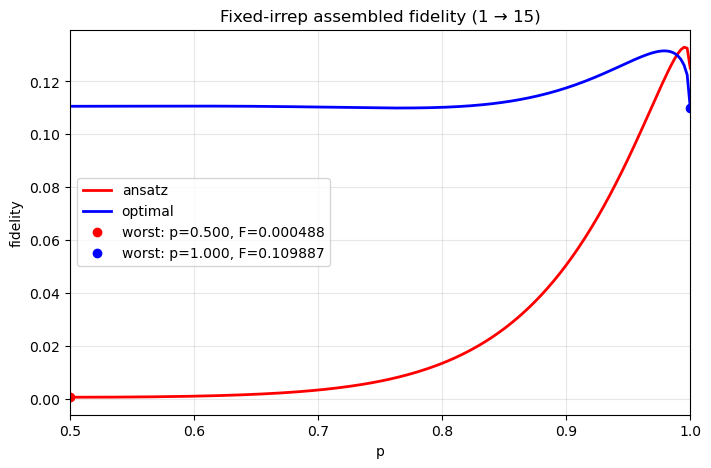

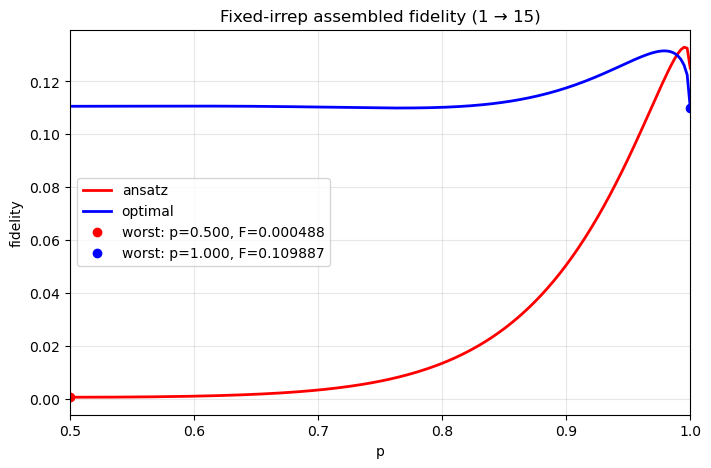

In [10]:
# format: partition_out, partition_in
pair_coeff = {
    ((15,), (1,)): 1.0,
    # ((15,), (1,)): 1,
    # ((8,2), (1,)): 0.02,
    # ((9,1), (1,)): 0.03,
    # ((6,4), (1,)): 0.02,
    # ((2,2), (1,)): 0.0,
}
assembled = assemble_best_fixed_irrep_global_map(n_in, n_out, pair_coeff, "data/exact_irrep",)
ret = plot_assembled_fixed_irrep_fidelity(assembled)

nu_coefficients = {
    ((15,), (1,)) : {
        (14,) : 1.0
    }
}
assembled = assemble_mixed_nu_global_map(n_in, n_out, pair_coeff, nu_coefficients, "data/exact_irrep")
ret = plot_assembled_fixed_irrep_fidelity(assembled)